In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
lmda = 660e-9 #wave length of laser in meter (red)
#F = #focal length of the lens
#D = #beam diameter
#w0 = ((2*lmda*F)/((np.pi)*D)) #formula for beam waist.
w0 = 2.1e-5 #beam waist for the above light in meters
z0 = (np.pi)*(w0*w0)/lmda # Rayleigh range

In [3]:

# Load CSV with custom headers
# df = pd.read_csv(r'C:\Users\MARSHED\Downloads\D3\Calcirol\25.05.25\pi_2025_05_25_12_21_26\252_ca_oa.csv', 
#                  header=None, names=['ca', 'oa'])

df = pd.read_csv(r"C:\Users\MARSHED\Downloads\D3\Finalized\D-Balance\pi_2025_09_06_20_03_05\242_ca_oa.csv", 
                 header=None, names=['ca', 'oa'])
print(df)


# df1=pd.read_csv(r'C:\Users\MARSHED\Downloads\pi_2025_09_28_16_01_33\233_ca_oa.csv',header=None, names=['ca', 'oa'])

# df2=pd.read_csv(r'C:\Users\MARSHED\Downloads\D3\Calcirol\25.05.25\pi_2025_05_25_12_21_26\253.csv', header=None)
# print(df2)

# df3 = pd.read_csv(r'C:\Users\MARSHED\Downloads\254_ca_oa.csv', 
#                  header=None, names=['ca', 'oa'])


         ca    oa
0      1395  3891
1      1441  3963
2      1425  3943
3      1411  3917
4      1396  3890
...     ...   ...
11995  1424  3957
11996  1423  3951
11997  1423  3920
11998  1407  3901
11999  1402  3922

[12000 rows x 2 columns]


In [4]:
# Normalize the 'ca' and 'oa' columns separately
df['ca/oa'] = df['ca'] / df['oa']


In [5]:
df

,ca,oa,ca/oa
0,1395,3891,0.358520
1,1441,3963,0.363613
2,1425,3943,0.361400
3,1411,3917,0.360225
4,1396,3890,0.358869
...,...,...,...
11995,1424,3957,0.359869
11996,1423,3951,0.360162
11997,1423,3920,0.363010
11998,1407,3901,0.360677


In [6]:
def meter_to_index(x):
    return x / 1e-5

def index_to_meter(x):
    return x * 1e-5

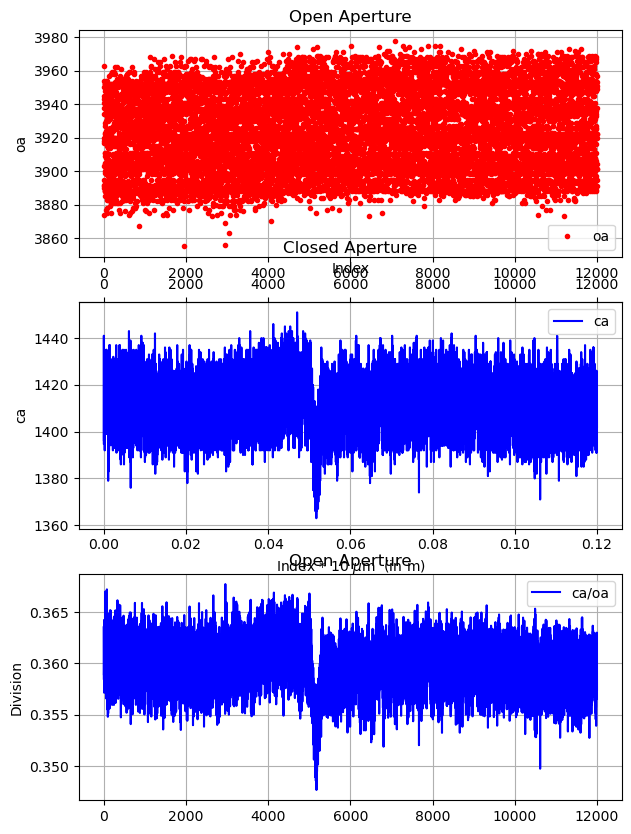

In [7]:
import matplotlib.pyplot as plt

# Create 2 subplots stacked vertically
fig, axs = plt.subplots(3, 1, figsize=(7, 10))

# 1. ca plot
axs[1].plot(df.index*.00001, df['ca'], color='blue', label='ca')
axs[1].set_xlabel('Index * 10 $\mu$m  (in m)')



secax = axs[1].secondary_xaxis('top', functions=(meter_to_index, index_to_meter))
secax.set_xlabel('Index')
axs[1].set_ylabel('ca')
axs[1].set_title('Closed Aperture')
axs[1].legend()
axs[1].grid(True)

# 2. oa plot
axs[0].plot(df.index, df['oa'], '.', color='red', label='oa')
axs[0].set_ylabel('oa')
axs[0].set_title('Open Aperture')
axs[0].legend()
axs[0].grid(True)
# 3. oa plot
axs[2].plot(df.index, df['ca/oa'], color='blue', label='ca/oa')
axs[2].set_ylabel('Division')
axs[2].set_title('Open Aperture')
axs[2].legend()
axs[2].grid(True)

In [8]:

# Lock the first 300 and last 300 rows for mean calculation on 'ca' and 'oa' columns
mean_ca = pd.concat([df['ca'].head(300), df['ca'].tail(300)]).mean()
mean_oa = pd.concat([df['oa'].head(2000), df['oa'].tail(300)]).mean()
mean_ca_oa = pd.concat([df['ca/oa'].head(300), df['ca/oa'].tail(300)]).mean()

# Normalize the 'ca' and 'oa' columns separately
df['normalized_ca'] = df['ca'] / mean_ca
# df['normalized_oa'] = df['oa'] / mean_oa
df['normalized_oa'] = df['oa'] / mean_oa
df['normalized_ca/oa'] = df['ca/oa'] / mean_ca_oa

# Remove zero points from the normalized data
df_nonzero = df[(df['normalized_ca'] != 0) & (df['normalized_oa'] != 0)]

# Optionally display the result
print(df_nonzero.head())

     ca    oa     ca/oa  normalized_ca  normalized_oa  normalized_ca/oa
0  1395  3891  0.358520       0.987006       0.992558          0.995118
1  1441  3963  0.363613       1.019553       1.010924          1.009257
2  1425  3943  0.361400       1.008232       1.005822          1.003113
3  1411  3917  0.360225       0.998327       0.999190          0.999851
4  1396  3890  0.358869       0.987714       0.992303          0.996088


In [9]:
df

,ca,oa,ca/oa,normalized_ca,normalized_oa,normalized_ca/oa
0,1395,3891,0.358520,0.987006,0.992558,0.995118
1,1441,3963,0.363613,1.019553,1.010924,1.009257
2,1425,3943,0.361400,1.008232,1.005822,1.003113
3,1411,3917,0.360225,0.998327,0.999190,0.999851
4,1396,3890,0.358869,0.987714,0.992303,0.996088
...,...,...,...,...,...,...
11995,1424,3957,0.359869,1.007525,1.009394,0.998863
11996,1423,3951,0.360162,1.006817,1.007863,0.999677
11997,1423,3920,0.363010,1.006817,0.999955,1.007583
11998,1407,3901,0.360677,0.995497,0.995109,1.001106


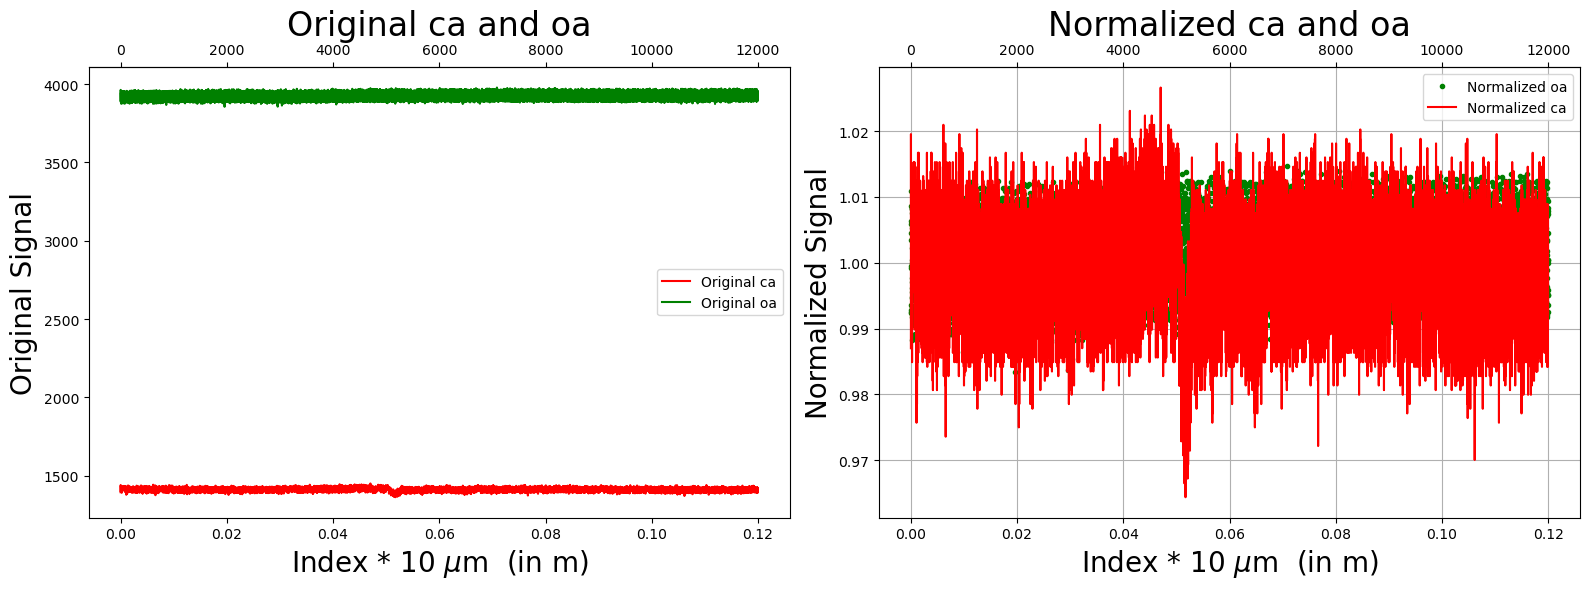

In [13]:
# --- Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharex=True)


# plt.rcParams.update({
#     'axes.titlesize': 20,
#     'axes.labelsize': 20,
#     'xtick.labelsize': 20,
#     'ytick.labelsize': 20,
#     'legend.fontsize': 20
# })

# Plot original ca and oa
axs[0].plot(df.index*.00001, df['ca'], label='Original ca', color='red', alpha=1)
axs[0].plot(df.index*.00001, df['oa'], label='Original oa', color='green', alpha=1)
secax = axs[0].secondary_xaxis('top', functions=(meter_to_index, index_to_meter))
#secax.set_xlabel('Index', fontsize=20)
axs[0].set_xlabel('Index * 10 $\mu$m  (in m)', fontsize=20 )
axs[0].set_ylabel('Original Signal', fontsize=20)
axs[0].legend()
axs[0].set_title('Original ca and oa', fontsize=24)
plt.grid('True')
# Plot normalized ca and oa

axs[1].plot(df.index*.00001, df['normalized_oa'], '.', label='Normalized oa', color='green')
axs[1].plot(df.index*.00001, df['normalized_ca'], label='Normalized ca', color='red')
#axs[1].plot(df.index*.00001, df['normalized_ca/oa'], label='Division', color='blue')
secax = axs[1].secondary_xaxis('top', functions=(meter_to_index, index_to_meter))
#secax.set_xlabel('Index', fontsize=20)
axs[1].set_ylabel('Normalized Signal', fontsize=20)
axs[1].set_xlabel('Index * 10 $\mu$m  (in m)', fontsize=20 )
axs[1].legend()
axs[1].set_title('Normalized ca and oa', fontsize=24)
plt.grid('True')

plt.tight_layout()
plt.show()

In [17]:
# # Step 1: Slice the range from index 4000 to 7000
#subset = df['normalized_ca'].iloc[4000:6000]  # Include index 7000
# #subset1 = df['normalized_ca/oa'].iloc[4000:6000]
# # subset2 = df['normalized_oa'].iloc[4000:6000]
# # Step 2: Find min and max values and their positions in the full DataFrame
# min_val = subset.min()
# max_val = subset.max()

# min_pos = subset.idxmin()
# max_pos = subset.idxmax()

# # # Step 3: Sort the indices so we can slice correctly
# # start_idx = min(min_pos, max_pos)
# # end_idx = max(min_pos, max_pos)

# # Step 4: Extract the values in between min and max index
# between_values = df.loc[max_pos:min_pos, 'normalized_ca']
# # Create a new DataFrame using the index as x, and values as normalized_ca
# df_between = pd.DataFrame({
#     'x': between_values.index,
#     'normalized_ca': between_values.values
# })
# print(df_between)

In [14]:
# Step 1: Slice the range from index 4000 to 7000
subset = df['normalized_ca/oa'].iloc[4000:7000]  # Include index 7000
#subset1 = df['normalized_ca/oa'].iloc[4000:6000]
# subset2 = df['normalized_oa'].iloc[4000:6000]
# Step 2: Find min and max values and their positions in the full DataFrame
min_val = subset.min()
max_val = subset.max()
min_pos = subset.idxmin()
max_pos = subset.idxmax()

# Step 3: Sort the indices so we can slice correctly
start_idx = min(min_pos, max_pos)
end_idx = max(min_pos, max_pos)

# Step 4: Extract the values in between min and max index
between_values = df.loc[start_idx:end_idx, 'normalized_ca/oa']
# Create a new DataFrame using the index as x, and values as normalized_ca
df_between = pd.DataFrame({
    'x': between_values.index,
    'normalized_ca/oa': between_values.values
})
print(df_between)

         x  normalized_ca/oa
0     4138          1.018418
1     4139          1.008736
2     4140          1.010742
3     4141          1.000944
4     4142          1.007907
...    ...               ...
1032  5170          0.983598
1033  5171          0.976306
1034  5172          0.984970
1035  5173          0.981163
1036  5174          0.965007

[1037 rows x 2 columns]


In [15]:
# Number of rows to drop from start and end
n = len(df_between)
drop_count = int(0.1 * n)

# Slice the DataFrame to keep middle 70%
cropped_df = df_between.iloc[drop_count : n - drop_count]

# 4. Extract x and normalized_ca arrays for regression
mid_data_x = cropped_df['x'].values
mid_data_y = cropped_df['normalized_ca/oa'].values
coefficients = np.polyfit(mid_data_y, mid_data_x, 1) # 1 indicates degree of polynomial

# slope = coefficients[0]
# intercept = coefficients[1]
# x_pred = (1/slope) - (intercept/slope)
# print(x_pred)

slope = coefficients[0]
intercept = coefficients[1]
x_pred = slope * 1 + intercept
print(x_pred)

# 1. Extract original index as x
x = df.index.to_numpy()

# 2. Define your transform function
def transform_x(x, x_pred):
    return (x - x_pred) * 1e-5 

# 3. Compute transformed x
x_transformed = transform_x(x, x_pred)

# 4. Add to DataFrame as a new column
df['x_position'] = x_transformed

4675.440697221927


In [68]:
cropped_df

,x,normalized_ca/oa
110,4110,1.012784
111,4111,1.022854
112,4112,1.020584
113,4113,1.019867
114,4114,1.011610
...,...,...
990,4990,0.999454
991,4991,0.969649
992,4992,1.017813
993,4993,1.006473


In [26]:
df

,ca,oa,ca/oa,normalized_ca,normalized_oa,normalized_ca/oa,x_position
0,1373,3899,0.352142,0.996832,0.994791,1.002045,-0.050824
1,1363,3897,0.349756,0.989572,0.994281,0.995257,-0.050814
2,1403,3953,0.354920,1.018613,1.008569,1.009952,-0.050804
3,1389,3937,0.352807,1.008449,1.004487,1.003938,-0.050794
4,1387,3909,0.354822,1.006996,0.997343,1.009673,-0.050784
...,...,...,...,...,...,...,...
11995,1375,3915,0.351213,0.998284,0.998874,0.999404,0.069126
11996,1369,3891,0.351838,0.993928,0.992750,1.001180,0.069136
11997,1383,3931,0.351819,1.004092,1.002956,1.001127,0.069146
11998,1379,3950,0.349114,1.001188,1.007803,0.993430,0.069156


In [16]:
# # Step 1: Slice the range from index 4000 to 7000
# subset = df['normalized_ca'].iloc[4000:7000]  # Include index 7000
# #subset1 = df['normalized_ca/oa'].iloc[4000:6000]
# # subset2 = df['normalized_oa'].iloc[4000:6000]
# # Step 2: Find min and max values and their positions in the full DataFrame
# min_val = subset.min()
# max_val = subset.max()

# min_pos = subset.idxmin()
# max_pos = subset.idxmax()

# # Step 3: Sort the indices so we can slice correctly
# start_idx = min(min_pos, max_pos)
# end_idx = max(min_pos, max_pos)

# # Step 4: Extract the values in between min and max index
# between_values = df.loc[max_pos:min_pos, 'normalized_ca']
# # Create a new DataFrame using the index as x, and values as normalized_ca
# df_between = pd.DataFrame({
#     'x': between_values.index,
#     'normalized_ca': between
#     _values.values
# })
# print(df_between)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3003188002.py, line 21)

In [17]:
# tmp_df= df_between
# tmp_df

,x,normalized_ca
0,4190,0.861068
1,4191,0.914330
2,4192,1.040087
3,4193,1.014936
4,4194,0.970551
...,...,...
1275,5465,1.003100
1276,5466,0.970551
1277,5467,1.004579
1278,5468,0.970551


In [20]:
# r = abs(min_pos - max_pos)+1
# upper_bound = int(min_pos - 0.15 * r)
# lower_bound = int(max_pos + 0.15 * r)


# # 3. Crop df_between based on these bounds — but df_between's index is default 0..N,
# #    so we need to filter rows where 'x' is within [lower_bound, upper_bound]
# cropped_df = df_between[(df_between['x'] >= lower_bound) & (df_between['x'] <= upper_bound)]

# # 4. Extract x and normalized_ca arrays for regression
# mid_data_x = cropped_df['x'].values
# mid_data_y = cropped_df['normalized_ca'].values
# # #5. Define your estimation function to regress x = b0 + b1 * y
# # def estimate_coef(y, x):  # Note the order: y first (independent), x second (dependent)
# #     n = np.size(y)
# #     m_y, m_x = np.mean(y), np.mean(x)
# #     SS_xy = np.sum(x * y) - n * m_x * m_y
# #     SS_yy = np.sum(y * y) - n * m_y * m_y
# #     b_1 = SS_xy / SS_yy
# #     b_0 = m_x - b_1 * m_y
# #     return b_0, b_1

# # # 6. Estimate coefficients using cropped data, fitting x = b0 + b1 * y
# # b0, b1 = estimate_coef(mid_data_y, mid_data_x)

# # # 7. Predict x for y=1 using the fitted model x = b0 + b1 * y
# # x_pred = b0 + b1 * 1
# # print(x_pred)

In [32]:
# r = abs(min_pos - max_pos)+1
# upper_bound = int(min_pos - 0.15 * r)
# lower_bound = int(max_pos + 0.15 * r)


# # 3. Crop df_between based on these bounds — but df_between's index is default 0..N,
# #    so we need to filter rows where 'x' is within [lower_bound, upper_bound]
# cropped_df = tmp_df[(df_between['x'] >= lower_bound) & (df_between['x'] <= upper_bound)]

# # 4. Extract x and normalized_ca arrays for regression
# mid_data_x = cropped_df['x'].values
# mid_data_y = cropped_df['normalized_ca'].values
# coefficients = np.polyfit(mid_data_x, mid_data_y, 1) # 1 indicates degree of polynomial

# slope = coefficients[0]
# intercept = coefficients[1]
# x_pred = (1/slope) - (intercept/slope)
# print(x_pred)

# # 1. Extract original index as x
# x = df.index.to_numpy()

# # 2. Define your transform function
# def transform_x(x, x_pred):
#     return (x - x_pred) * 1e-5 

# # 3. Compute transformed x
# x_transformed = transform_x(x, x_pred)

# # 4. Add to DataFrame as a new column
# df['x_position'] = x_transformed

TypeError: expected non-empty vector for x

In [22]:
# coefficients = np.polyfit(mid_data_x, mid_data_y, 1) # 1 indicates degree of polynomial

# slope = coefficients[0]
# intercept = coefficients[1]
# x_pred = (1/slope) - (intercept/slope)
# print(x_pred)

# coefficients = np.polyfit(mid_data_y, mid_data_x, 1) # 1 indicates degree of polynomial

# slope = coefficients[0]
# intercept = coefficients[1]
# x_pred = slope*1 + intercept
# print(x_pred)

In [23]:
r,max_pos,lower_bound, min_pos,upper_bound

(355, 4869, 4922, 5223, 5169)

In [24]:
# # 1. Extract original index as x
# x = df.index.to_numpy()

# # 2. Define your transform function
# def transform_x(x, x_pred):
#     return (x - x_pred) * 1e-5 

# # 3. Compute transformed x
# x_transformed = transform_x(x, x_pred)

# # 4. Add to DataFrame as a new column
# df['x_position'] = x_transformed

In [16]:
df

,ca,oa,ca/oa,normalized_ca,normalized_oa,normalized_ca/oa,x_position
0,1395,3891,0.358520,0.987006,0.992558,0.995118,-0.046754
1,1441,3963,0.363613,1.019553,1.010924,1.009257,-0.046744
2,1425,3943,0.361400,1.008232,1.005822,1.003113,-0.046734
3,1411,3917,0.360225,0.998327,0.999190,0.999851,-0.046724
4,1396,3890,0.358869,0.987714,0.992303,0.996088,-0.046714
...,...,...,...,...,...,...,...
11995,1424,3957,0.359869,1.007525,1.009394,0.998863,0.073196
11996,1423,3951,0.360162,1.006817,1.007863,0.999677,0.073206
11997,1423,3920,0.363010,1.006817,0.999955,1.007583,0.073216
11998,1407,3901,0.360677,0.995497,0.995109,1.001106,0.073226


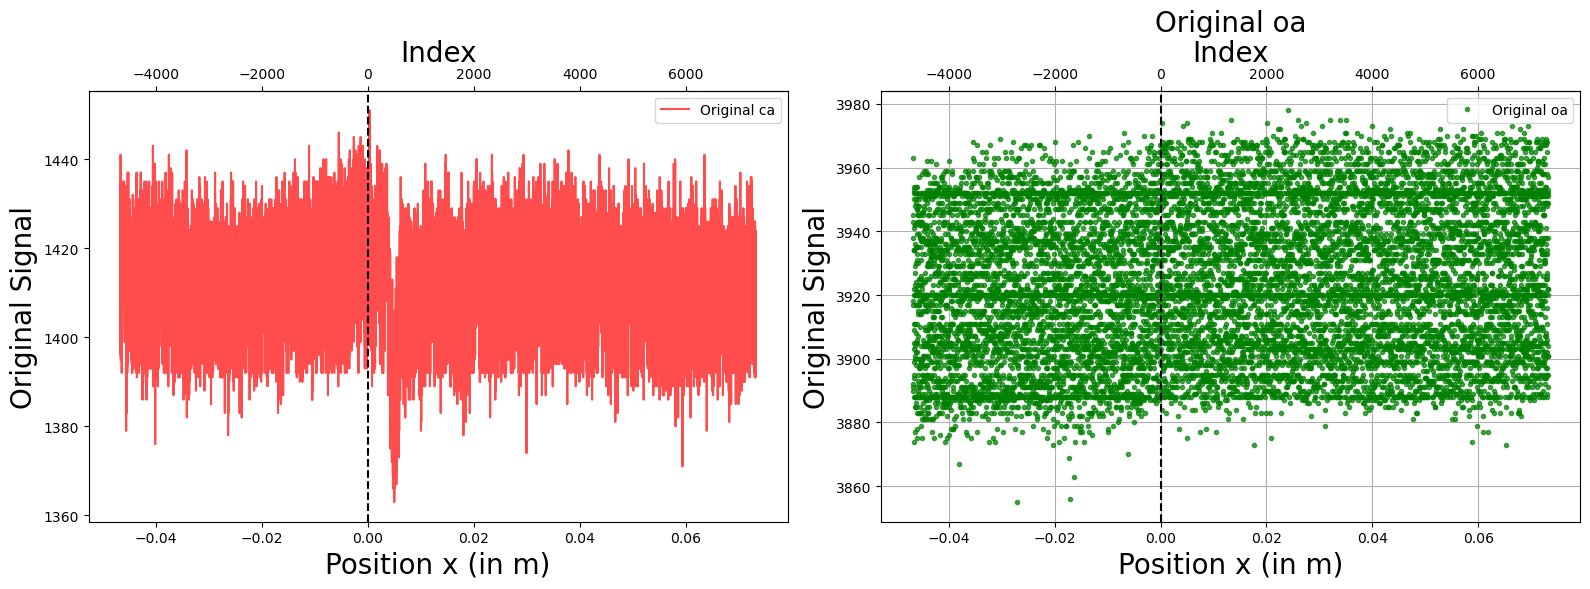

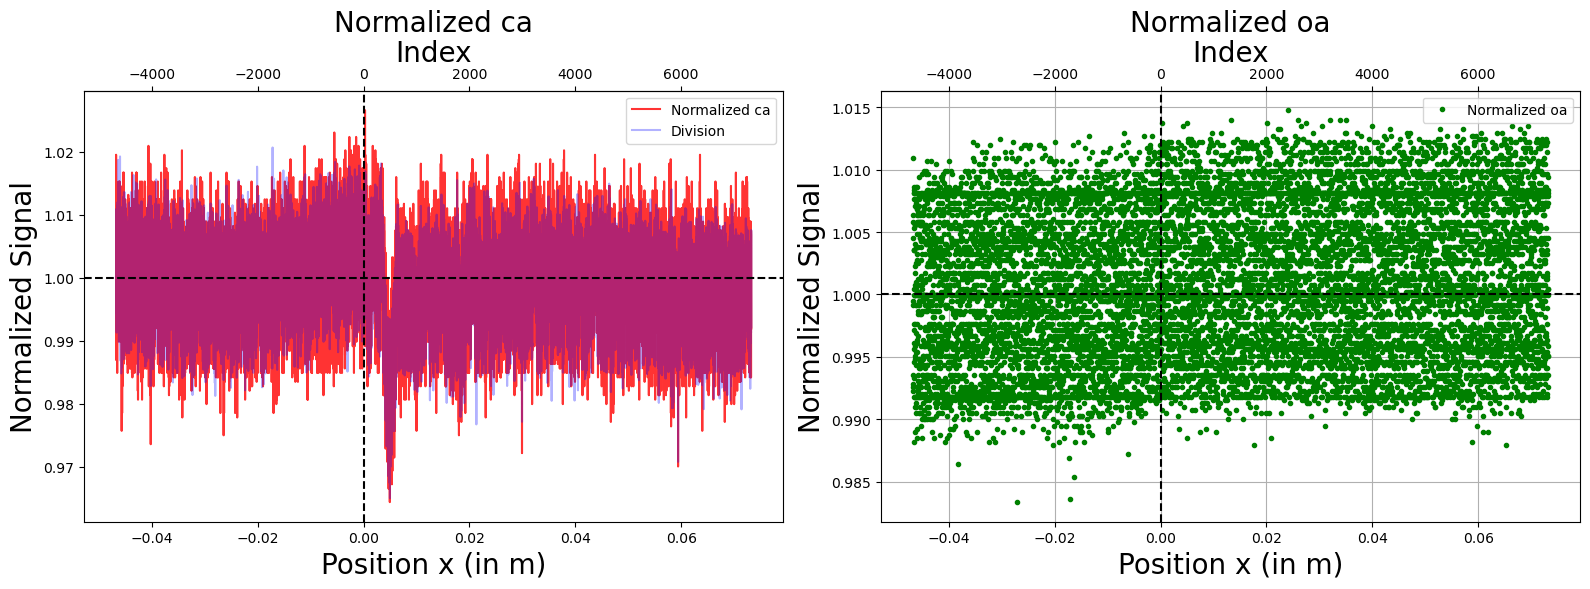

In [17]:
# --- Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Plot original ca and oa
axs[0].plot(df['x_position'], df['ca'], label='Original ca', color='red', alpha=0.7)
#axs[0].plot(df['x_position'], df['oa'], label='Original oa', color='green', alpha=0.7)
secax = axs[0].secondary_xaxis('top', functions=(meter_to_index, index_to_meter))
secax.set_xlabel('Index', fontsize=20)
axs[0].axvline(x=0, color='black', linestyle='--')
#axs[0].axhline(y=1, color='black', linestyle='--')
axs[0].set_xlabel('Position x (in m)', fontsize=20)
axs[0].set_ylabel('Original Signal', fontsize=20)
axs[0].legend()
axs[1].set_title('Original ca', fontsize=20)

# Plot original ca and oa
#axs[1].plot(df['x_position'], df['ca'], label='Original ca', color='red', alpha=0.7)
axs[1].plot(df['x_position'], df['oa'],'.', label='Original oa', color='green', alpha=0.7)
secax = axs[1].secondary_xaxis('top', functions=(meter_to_index, index_to_meter))
secax.set_xlabel('Index', fontsize=20)
axs[1].axvline(x=0, color='black', linestyle='--')
#axs[0].axhline(y=1, color='black', linestyle='--')
axs[1].set_xlabel('Position x (in m)', fontsize=20)
axs[1].set_ylabel('Original Signal', fontsize=20)
axs[1].legend()
axs[1].set_title('Original oa', fontsize=20)


plt.grid('True')
plt.tight_layout()
plt.show()
# Plot normalized ca and oa
# --- Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

#axs[1].plot(df['x_position'], df['normalized_oa'], label='Normalized oa', color='green', alpha=1)
axs[0].plot(df['x_position'], df['normalized_ca'], label='Normalized ca', color='red', alpha=0.8)
axs[0].plot(df['x_position'], df['normalized_ca/oa'], label='Division', color='blue', alpha=0.3)
secax = axs[0].secondary_xaxis('top', functions=(meter_to_index, index_to_meter))
secax.set_xlabel('Index', fontsize=20)
axs[0].set_ylabel('Normalized Signal', fontsize=20)
axs[0].set_xlabel('Position x (in m)', fontsize=20)
axs[0].axvline(x=0, color='black', linestyle='--')
axs[0].axhline(y=1, color='black', linestyle='--')
axs[0].legend()
axs[0].set_title('Normalized ca', fontsize=20)
# Plot normalized ca and oa

axs[1].plot(df['x_position'], df['normalized_oa'],'.', label='Normalized oa', color='green', alpha=1)
#axs[2].plot(df['x_position'], df['normalized_ca'], label='Normalized ca', color='red', alpha=0.8)
#axs[1].plot(df['x_position'], df['normalized_ca/oa'], label='Division', color='blue', alpha=0.3)
secax = axs[1].secondary_xaxis('top', functions=(meter_to_index, index_to_meter))
secax.set_xlabel('Index', fontsize=20)

axs[1].set_ylabel('Normalized Signal', fontsize=20)
axs[1].set_xlabel('Position x (in m)', fontsize=20)
axs[1].axvline(x=0, color='black', linestyle='--')
axs[1].axhline(y=1, color='black', linestyle='--')
axs[1].legend()
axs[1].set_title('Normalized oa', fontsize=20)

plt.grid('True')
plt.tight_layout()
plt.show()

In [18]:
def reduce_data(df, group_size, x_col, y_cols):
    grouped = df.copy()
    grouped['group'] = grouped.index // group_size

    # Build aggregation dictionary
    agg_dict = {x_col: 'mean'}
    for col in y_cols:
        agg_dict[col] = ['mean', 'std']

    reduced_df = grouped.groupby('group').agg(agg_dict).reset_index(drop=True)

    # Flatten column names
    reduced_df.columns = ['x_position'] + [f'{col}_{stat}' for col in y_cols for stat in ['mean', 'std']]

    return reduced_df
    

In [19]:
reduced_df = reduce_data(df, group_size=10, x_col='x_position', y_cols=['normalized_ca', 'normalized_oa', 'normalized_ca/oa'])

In [20]:
reduced_df

,x_position,normalized_ca_mean,normalized_ca_std,normalized_oa_mean,normalized_oa_std,normalized_ca/oa_mean,normalized_ca/oa_std
0,-0.046709,1.001794,0.011283,0.999751,0.006847,1.002741,0.006154
1,-0.046609,1.002289,0.006286,1.000670,0.007119,1.002360,0.006715
2,-0.046509,1.001935,0.009119,1.000721,0.005446,1.001923,0.006215
3,-0.046409,1.004624,0.005129,0.998221,0.005778,1.007156,0.006337
4,-0.046309,1.005544,0.005122,0.999114,0.005776,1.007171,0.005159
...,...,...,...,...,...,...,...
1195,0.072791,0.998327,0.004362,1.001460,0.006543,0.997611,0.006038
1196,0.072891,0.998114,0.006476,1.003629,0.007132,0.995246,0.007472
1197,0.072991,0.995001,0.010642,1.001511,0.006776,0.994199,0.006391
1198,0.073091,0.995567,0.008063,1.001511,0.006727,0.994778,0.004891


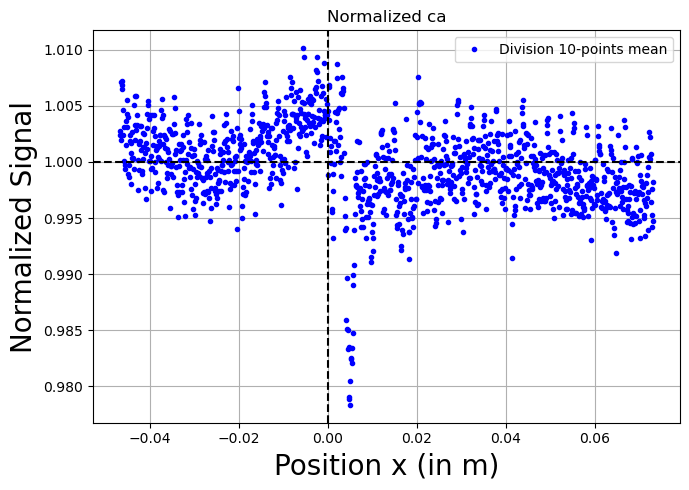

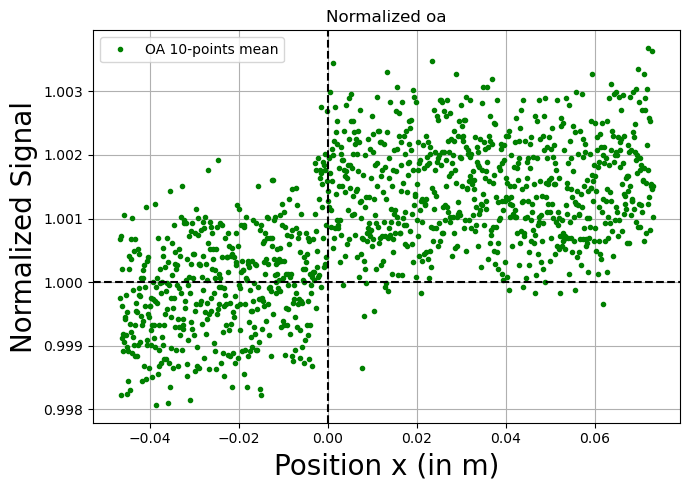

In [22]:

# Assuming df is your DataFrame and it has the columns used below
fig, ax = plt.subplots(figsize=(7, 5))

# Plotting lines
#ax.plot(reduced_df['x_position'], reduced_df['normalized_oa_mean'], label='OA 10-points mean', color='green', alpha=1)
#ax.plot(reduced_df['x_position'], reduced_df['normalized_ca_mean'],'^', label='CA 10-points mean', color='red', alpha=1)
ax.plot(reduced_df['x_position'], reduced_df['normalized_ca/oa_mean'],'.', label='Division 10-points mean', color='blue', alpha=1)
# Axis labels
ax.set_ylabel('Normalized Signal', fontsize=20)
ax.set_xlabel('Position x (in m)', fontsize=20)

# Reference lines
ax.axvline(x=0, color='black', linestyle='--')
ax.axhline(y=1, color='black', linestyle='--')

# Title, legend, and grid
ax.set_title('Normalized ca')
ax.legend()
ax.grid(True)

# Layout and display
plt.tight_layout()
plt.show()


# Assuming df is your DataFrame and it has the columns used below
fig, ax = plt.subplots(figsize=(7, 5))

# Plotting lines
ax.plot(reduced_df['x_position'], reduced_df['normalized_oa_mean'], '.', label='OA 10-points mean', color='green', alpha=1)
#ax.plot(reduced_df['x_position'], reduced_df['normalized_ca_mean'], label='CA 10-points mean', color='red', alpha=1)
#ax.plot(reduced_df['x_position'], reduced_df['normalized_ca/oa_mean'], label='Division 10-points mean', color='blue', alpha=1)
# Axis labels
ax.set_ylabel('Normalized Signal', fontsize=20)
ax.set_xlabel('Position x (in m)', fontsize=20)

# Reference lines
ax.axvline(x=0, color='black', linestyle='--')
ax.axhline(y=1, color='black', linestyle='--')

# Title, legend, and grid
ax.set_title('Normalized oa')
ax.legend()
ax.grid(True)

# Layout and display
plt.tight_layout()
plt.show()

In [23]:
# Assuming your dataset is in a DataFrame named df
subset = reduced_df[(reduced_df['x_position'] > -0.02) & (reduced_df['x_position'] < 0.02)]

# Check the result
print(subset.head())
print(len(subset), "rows selected")

     x_position  normalized_ca_mean  normalized_ca_std  normalized_oa_mean  \
268   -0.019909            1.004977           0.004060            1.001154   
269   -0.019809            1.000520           0.006035            0.999649   
270   -0.019709            0.999529           0.004622            0.999241   
271   -0.019609            1.001581           0.005115            0.999904   
272   -0.019509            1.001369           0.003578            1.000899   

     normalized_oa_std  normalized_ca/oa_mean  normalized_ca/oa_std  
268           0.006919               1.004558              0.003721  
269           0.006088               1.001608              0.006672  
270           0.006809               1.001035              0.006582  
271           0.006247               1.002420              0.006715  
272           0.006416               1.001220              0.006966  
400 rows selected


In [24]:
print(reduced_df.columns.tolist())

['x_position', 'normalized_ca_mean', 'normalized_ca_std', 'normalized_oa_mean', 'normalized_oa_std', 'normalized_ca/oa_mean', 'normalized_ca/oa_std']


In [25]:

# Step 1: Subset (assuming df already exists)
subset = reduced_df[(reduced_df['x_position'] > -0.02) & (reduced_df['x_position'] < 0.02)]


# Step 2: Find min and max positions of your column of interest
col = 'normalized_ca/oa_mean'

min_pos = subset[col].idxmin()
max_pos = subset[col].idxmax()

# Sort indices for slicing
start_idx, end_idx = sorted([min_pos, max_pos])


# Step 3: Extract between those indices
between_values = reduced_df.loc[start_idx:end_idx, [col, 'x_position']].copy()
between_values.rename(columns={'x_position': 'x'}, inplace=True)
print(between_values)

# Step 4: Trim 10% from both ends
n = len(between_values)
drop_count = int(0.1 * n)
cropped_df = between_values.iloc[drop_count : n - drop_count]

# Step 5: Regression (y vs x)
mid_data_x = cropped_df['x'].values
mid_data_y = cropped_df[col].values

coefficients = np.polyfit(mid_data_x, mid_data_y, 1)
slope, intercept = coefficients

# Step 6: Predict x when y = 1
x_pred = (1 - intercept) / slope
print(f"slope={slope}, intercept={intercept}, x_pred={x_pred}")

# Step 7: Transform x_position
reduced_df['x_position'] = reduced_df['x_position'] - x_pred
print(reduced_df)

     normalized_ca/oa_mean         x
412               1.010132 -0.005509
413               1.009320 -0.005409
414               1.004305 -0.005309
415               1.005224 -0.005209
416               1.003934 -0.005109
..                     ...       ...
514               0.979070  0.004691
515               0.978896  0.004791
516               0.983541  0.004891
517               0.980514  0.004991
518               0.978353  0.005091

[107 rows x 2 columns]
slope=-0.5331182599417246, intercept=1.0031730893332411, x_pred=0.0059519426957687985
      x_position  normalized_ca_mean  normalized_ca_std  normalized_oa_mean  \
0      -0.052661            1.001794           0.011283            0.999751   
1      -0.052561            1.002289           0.006286            1.000670   
2      -0.052461            1.001935           0.009119            1.000721   
3      -0.052361            1.004624           0.005129            0.998221   
4      -0.052261            1.005544           0.00

In [26]:
# filtered_df = reduced_df[(reduced_df['x_position'] > -0.03) & (reduced_df['x_position'] < 0.03)]
filtered_df = reduced_df[reduced_df['x_position'].between(-0.03, 0.03)]
filtered_df

,x_position,normalized_ca_mean,normalized_ca_std,normalized_oa_mean,normalized_oa_std,normalized_ca/oa_mean,normalized_ca/oa_std
227,-0.029961,0.998397,0.006359,0.999930,0.006367,0.999199,0.006191
228,-0.029861,0.995426,0.007667,0.998731,0.006316,0.997424,0.007973
229,-0.029761,0.999883,0.005154,1.000899,0.006815,0.999729,0.006765
230,-0.029661,0.999388,0.008293,1.000389,0.005290,0.999719,0.007119
231,-0.029561,0.999388,0.008641,0.999216,0.006272,1.000902,0.008087
...,...,...,...,...,...,...,...
822,0.029539,0.996770,0.008817,1.001741,0.006221,0.995773,0.009520
823,0.029639,0.998327,0.006996,1.001154,0.006282,0.997906,0.006765
824,0.029739,0.997902,0.003421,1.001282,0.005885,0.997367,0.006523
825,0.029839,1.002430,0.009218,1.003068,0.006213,1.000084,0.007359


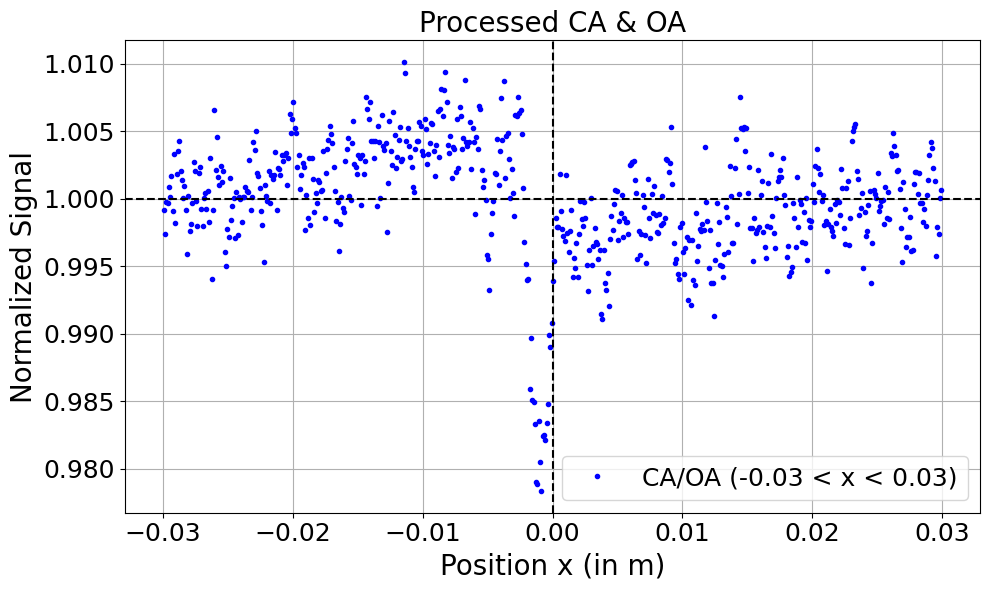

In [28]:
# Assuming df is your DataFrame and it has the columns used below
fig, ax = plt.subplots(figsize=(10, 6))
ax.tick_params(axis='both', labelsize=18) 

# Plotting lines
#ax.plot(filtered_df['x_position'], filtered_df['normalized_oa_mean'], label='OA (-0.03 < x < 0.03)', color='green', alpha=1)
#ax.plot(filtered_df['x_position'], filtered_df['normalized_ca_mean'], '.', label='CA (-0.03 < x < 0.03)', color='red', alpha=1)
ax.plot(filtered_df['x_position'], filtered_df['normalized_ca/oa_mean'], '.', label='CA/OA (-0.03 < x < 0.03)', color='blue', alpha=1)
# Axis labels
ax.set_ylabel('Normalized Signal', fontsize=20)
ax.set_xlabel('Position x (in m)', fontsize=20)

# Reference lines
ax.axvline(x=0, color='black', linestyle='--')
ax.axhline(y=1, color='black', linestyle='--')

# Title, legend, and grid
ax.set_title('Processed CA & OA', fontsize=20)
ax.legend(fontsize=18)
ax.grid(True)

# Layout and display
plt.tight_layout()
plt.show()

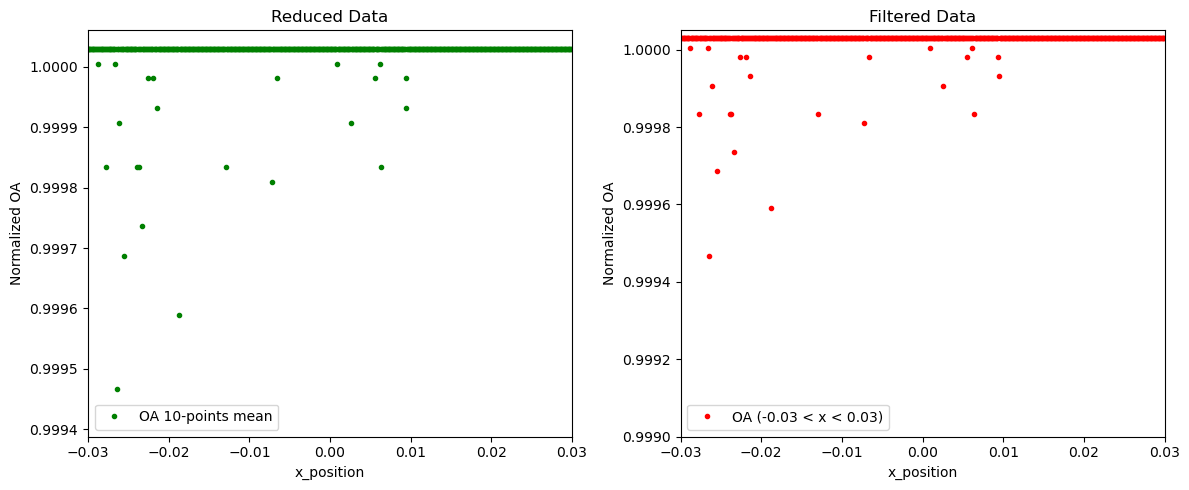

In [111]:
# Create a figure with 2 subplots (1 row, 2 columns)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # Adjust size as needed

# # Determine global min and max
# ymin = min(reduced_df['normalized_oa_mean'].min(), filtered_df['normalized_oa_mean'].min())
# ymax = max(reduced_df['normalized_oa_mean'].max(), filtered_df['normalized_oa_mean'].max())

# # Apply same limits to both
# axs[0].set_ylim(-1.5, 1.5)
# axs[1].set_ylim(-1.5, 1.5)

# First subplot: reduced_df
axs[0].plot(reduced_df['x_position'], reduced_df['normalized_oa_mean'], '.', 
            label='OA 10-points mean', color='green', alpha=1)
axs[0].set_xlim(-0.03, 0.03)
axs[0].set_title('Reduced Data')
axs[0].set_xlabel('x_position')
axs[0].set_ylabel('Normalized OA')
axs[0].legend()

# Second subplot: filtered_df
axs[1].plot(filtered_df['x_position'], filtered_df['normalized_oa_mean'], '.', 
            label='OA (-0.03 < x < 0.03)', color='red', alpha=1)
axs[1].set_ylim(0.999, 1.00005)
axs[1].set_xlim(-0.03, 0.03)
axs[1].set_title('Filtered Data')
axs[1].set_xlabel('x_position')
axs[1].set_ylabel('Normalized OA')
axs[1].legend()

plt.tight_layout()
plt.show()


In [75]:
print("Reduced y-range:", reduced_df['normalized_oa_mean'].min(), reduced_df['normalized_oa_mean'].max())
print("Filtered y-range:", filtered_df['normalized_oa_mean'].min(), filtered_df['normalized_oa_mean'].max())


print("Reduced:", reduced_df['normalized_oa_mean'].head(10))
print("Filtered:", filtered_df['normalized_oa_mean'].head(10))

Reduced y-range: 0.9994187863869026 1.0000293048880553
Filtered y-range: 0.999467627866995 1.0000293048880553
Reduced: 0    1.000029
1    0.999590
2    0.999980
3    1.000029
4    1.000029
5    0.999590
6    1.000029
7    1.000029
8    1.000029
9    1.000029
Name: normalized_oa_mean, dtype: float64
Filtered: 215    1.000029
216    1.000029
217    1.000029
218    1.000029
219    1.000029
220    1.000029
221    1.000029
222    1.000029
223    1.000029
224    1.000029
Name: normalized_oa_mean, dtype: float64


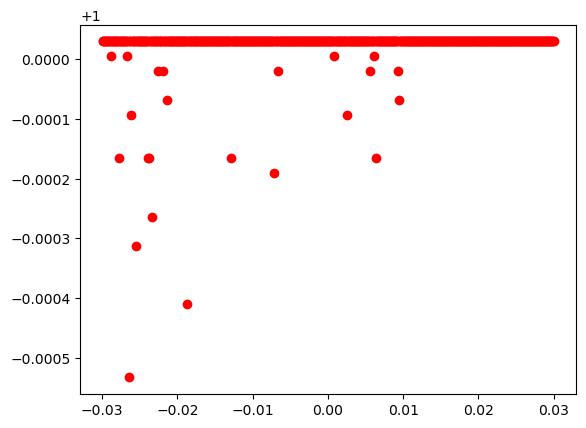

In [80]:

plt.scatter(filtered_df['x_position'], filtered_df['normalized_oa_mean'], c='r')

In [68]:
def compute_fit_stats(Yax, Yax2):
    """
    Compute fit statistics between observed (Yax) and predicted (Yax2) values.
    
    Returns:
        dict with:
            - R_sq   : Coefficient of determination
            - percent: R_sq in percentage
            - Y_diff : Absolute differences
            - RMSE   : Root Mean Squared Error
            - MAE    : Mean Absolute Error
            - MAPE   : Mean Absolute Percentage Error (if no zero values in Yax)
    """
    Yax = np.array(Yax, dtype=float)
    Yax2 = np.array(Yax2, dtype=float)

    if Yax.shape != Yax2.shape:
        raise ValueError("Input arrays must have the same shape.")

    diff = Yax - Yax2
    total_variance = np.sum((Yax - np.mean(Yax)) ** 2)
    residual_variance = np.sum(diff ** 2)

    # Handle case where Yax has zero variance
    if total_variance == 0:
        R_sq = 1.0 if np.allclose(Yax, Yax2) else 0.0
    else:
        R_sq = 1 - (residual_variance / total_variance)

    percent = R_sq * 100
    Y_diff = np.abs(diff)

    # Extra error metrics
    RMSE = np.sqrt(np.mean(diff ** 2))
    MAE = np.mean(Y_diff)
    MAPE = np.mean(np.abs(diff / Yax)) * 100 if np.all(Yax != 0) else np.nan

    return {
        'R_sq': R_sq,
        'percent': percent,
        'Y_diff': Y_diff,
        'RMSE': RMSE,
        'MAE': MAE,
        'MAPE': MAPE
    }

In [69]:
import numpy as np
from sklearn.metrics import r2_score
from scipy import stats

def compute_fit_stats(Yax, Yax2, sigma=None):
    """
    Compute fit statistics between observed (Yax) and predicted (Yax2) values.

    Args:
        Yax       : array-like, observed values
        Yax2      : array-like, predicted/fitted values
        sigma     : array-like or None, uncertainties for each point (default: 1)
        n_params  : int or None, number of fitted parameters (for reduced chi-squared)

    Returns:
        dict with:
            - R_sq_reg       : R^2 from regression formula
            - R_sq_pearson   : R^2 from Pearson correlation
            - R_sq_sklearn   : R^2 from sklearn.metrics.r2_score
            - percent        : R^2 (sklearn) in percentage
            - Y_diff         : Absolute differences
            - RMSE           : Root Mean Squared Error
            - MAE            : Mean Absolute Error
            - MAPE (%)       : Mean Absolute Percentage Error
            - chi_sq         : Chi-squared
            - chi_sq_red     : Reduced chi-squared (if n_params given)
    """
    Yax = np.array(Yax, dtype=float)
    Yax2 = np.array(Yax2, dtype=float)

    if Yax.shape != Yax2.shape:
        raise ValueError("Input arrays must have the same shape.")

    # Differences
    diff = Yax - Yax2
    Y_diff = np.abs(diff)

    # ---- R² (3 versions) ----
    total_variance = np.sum((Yax - np.mean(Yax)) ** 2)
    residual_variance = np.sum(diff ** 2)
    R_sq_reg = 1 - (residual_variance / total_variance) if total_variance != 0 else 1.0
    R_sq_reg= R_sq_reg*100
    
    r_value, _ = stats.pearsonr(Yax, Yax2)
    R_sq_pearson = r_value ** 2
    R_sq_pearson= R_sq_pearson*100

    R_sq_sklearn = r2_score(Yax, Yax2)
    R_sq_sklearn = R_sq_sklearn * 100

    # ---- Error metrics ----
    RMSE = np.sqrt(np.mean(diff ** 2))
    MAE = np.mean(Y_diff)
    MAPE = np.mean(np.abs(diff / Yax)) * 100 if np.all(Yax != 0) else np.nan

    # ---- Chi-squared ----
    if sigma is None:
        sigma = np.ones_like(Yax)
    else:
        sigma = np.array(sigma, dtype=float)
        if sigma.shape != Yax.shape:
            raise ValueError("sigma must have the same shape as Yax")

    chi_sq = np.sum((diff / sigma) ** 2)
    
    return {
        'Y_diff': Y_diff,
        'R_sq_reg': R_sq_reg,
        'R_sq_pearson': R_sq_pearson,
        'R_sq_sklearn': R_sq_sklearn,
        'RMSE': RMSE,
        'MAE': MAE,
        'MAPE (%)': MAPE,
        'chi_sq': chi_sq
    }


0.0036000000000000003


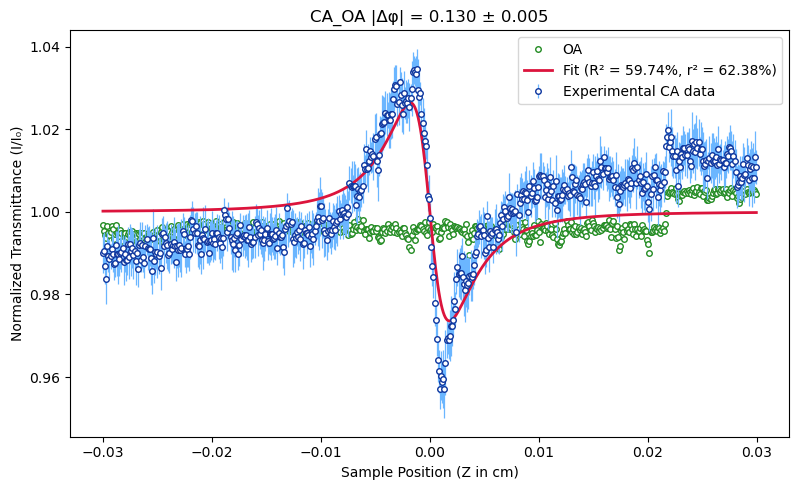

In [72]:
# Extract arrays from df
Xax = filtered_df['x_position'].to_numpy()              # in meters
Xcm = Xax * 100                       # convert to centimeters
x = Xax / z0                         # normalized Z
Yax = filtered_df['normalized_ca_mean'].to_numpy()

# defining the curve fitting function as "zscan"
def zscan(z,phi):
    x=z/z0
    T = 1 +(((4*x)/(((1 + x**2) * (9 + x**2))))*phi) #closed aparture Z-scan formula
    return T

# Using the Scipy curve fit module
popt, pcov = curve_fit(zscan, Xax, Yax) # fitting the "zscan function", finding the optimized parameter 'popt' and its coverience 'pcov'
Yax2 = zscan(Xax, *popt) # getting predicted values from the "zscan" function and naming them as "Yax3"

# Extract fit params
delphi = popt[0]
delphi_err = np.sqrt(pcov[0][0])
Tpv = max(Yax2) - min(Yax2)
Tp = np.argmax(Yax2)
Tv = np.argmin(Yax2)
Zpv = abs((x[Tv] - x[Tp]) * z0)
print(Zpv)

# fit_stats = compute_fit_stats(Yax, Yax2, sigma=filtered_df['normalized_ca/oa_std'])
# for k, v in fit_stats.items():
#     print(f"{k}: {v}")
    
R_sq=fit_stats['R_sq_reg']
r_sq = fit_stats['R_sq_pearson']
    
# Plotting
plt.figure(figsize=(1.618 * 5, 5))
plt.title(rf"CA_OA |Δφ| = {abs(delphi):.3f} ± {delphi_err:.3f}")
plt.ylabel(r"Normalized Transmittance (I/I₀)", fontsize=10)
plt.xlabel("Sample Position (Z in cm)", fontsize=10)
#plt.xlim(-3, 3)

plt.plot(Xax, filtered_df['normalized_oa_mean'], '.', color='#228B22',
         markersize=8, mfc='white', label='OA')
# plt.errorbar(Xcm, Yax, yerr=filtered_df['normalized_ca/oa_std'], fmt='.', color='#0C359E', ecolor='lightskyblue', elinewidth=0.9, markersize=8, mfc='w', label='Experimental data')
plt.errorbar(Xax, Yax, yerr=filtered_df['normalized_ca/oa_std'], 
             fmt='.', color='#0C359E', ecolor='#6bb6ff', elinewidth=0.9, 
             markersize=8, mfc='white', label='Experimental CA data')

plt.plot(
    Xax, Yax2, '-', color='#DC143C', linewidth=2,
    label=f'Fit (R² = {R_sq:.2f}%, r² = {r_sq:.2f}%)'
)
plt.legend()
plt.tight_layout()
plt.show()


<ErrorbarContainer object of 3 artists>

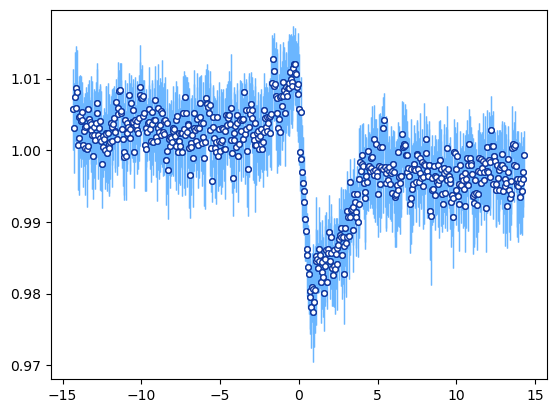

In [42]:
plt.errorbar(x, Yax, yerr=filtered_df['normalized_ca/oa_std'], 
             fmt='.', color='#0C359E', ecolor='#6bb6ff', elinewidth=0.9, 
             markersize=8, mfc='white', label='Experimental CA data')
plt.errorbar(x, Yax, yerr=filtered_df['normalized_ca/oa_std'], 
             fmt='.', color='#0C359E', ecolor='#6bb6ff', elinewidth=0.9, 
             markersize=8, mfc='white', label='Experimental CA data')

In [160]:
# Find indices of max and min
idx_max = np.argmax(Yax)
idx_min = np.argmin(Yax)

# Get x_position values for those indices
x_pos_max = Xax[idx_max]
x_pos_min = Xax[idx_min]

# Get the actual max/min values of Yax
y_max = Yax[idx_max]
y_min = Yax[idx_min]

# Calculate peak-to-valley delta
Zpv = abs(x_pos_max - x_pos_min)
z0 = Zpv/1.7

# Print results
print(f"Maximum value: {y_max:.6f} at x_position = {x_pos_max:.6f} m")
print(f"Minimum value: {y_min:.6f} at x_position = {x_pos_min:.6f} m")
print(f"ΔZpv (Peak-to-Valley difference): {Zpv:.6f}")
print(f"z0 (Rayleigh Range): {z0:.6f}")

lmda = 662e-9   # in meters

# Compute beam waist (w0)
w0 = np.sqrt((z0 * lmda) / np.pi)
print(f"Beam waist (w0): {w0:.6e} m")


Maximum value: 1.021978 at x_position = -0.000968 m
Minimum value: 0.961776 at x_position = 0.001432 m
ΔZpv (Peak-to-Valley difference): 0.002400
z0 (Rayleigh Range): 0.001412
Beam waist (w0): 1.724786e-05 m


Y_diff: [7.22018158e-03 5.39613560e-03 3.64782006e-03 4.09584989e-03
 7.64906000e-03 4.53747391e-03 9.71464093e-04 7.13872710e-03
 2.62483053e-03 3.21328609e-03 2.61382801e-03 2.92321170e-03
 1.79361349e-03 3.84494481e-03 4.68450323e-03 1.89808373e-03
 6.96593832e-03 4.62696000e-04 3.65010787e-03 5.84625113e-04
 3.75904270e-03 3.37384848e-03 2.16141898e-03 1.56205841e-03
 2.59689751e-03 7.86125162e-03 2.56626929e-03 4.16329471e-03
 4.53980093e-03 1.02134373e-02 5.96561537e-03 6.94358519e-03
 1.11024678e-02 7.83918789e-03 2.45528284e-03 7.22002513e-03
 6.94930582e-03 2.10884845e-03 6.20527958e-03 4.16708546e-03
 2.33953618e-03 2.89297259e-03 5.40220217e-05 1.61890662e-03
 1.39844116e-03 2.54124063e-03 5.02561613e-03 1.08054985e-03
 8.95387044e-04 2.11397482e-03 5.60430138e-03 2.56801601e-03
 4.40551459e-04 7.02356298e-04 5.27392878e-03 2.61626620e-03
 2.53362079e-03 3.35979474e-03 5.32199649e-03 9.40479696e-03
 6.82279072e-03 4.92239378e-03 4.99112206e-03 6.42308519e-03
 3.05098986e-03 

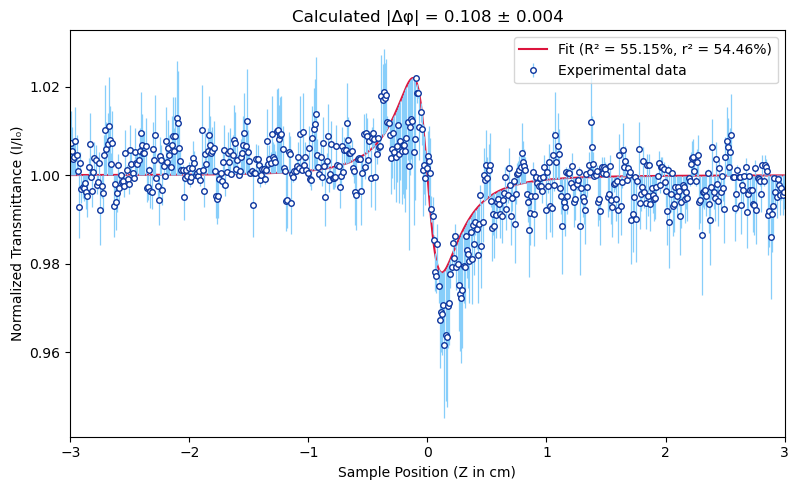

In [159]:
# Extract arrays from df
Xax = df1['x'].to_numpy()              # in meters
Xcm = Xax * 100                       # convert to centimeters
x = Xax / z0                         # normalized Z
Yax = df1['I/I0'].to_numpy()

# defining the curve fitting function as "zscan"
def zscan(x,phi):
   T = 1 +(((4*x)/(((1 + x**2) * (9 + x**2))))*phi) #closed aparture Z-scan formula
   return T

# Using the Scipy curve fit module
popt, pcov = curve_fit(zscan, x, Yax) # fitting the "zscan function", finding the optimized parameter 'popt' and its coverience 'pcov'
Yax2 = zscan(x, *popt) # getting predicted values from the "zscan" function and naming them as "Yax3"

delphi = popt[0]
delphi_err = np.sqrt(pcov[0][0])

fit_stats = compute_fit_stats(Yax, Yax2)
for k, v in fit_stats.items():
    print(f"{k}: {v}")
    
Y_diff = fit_stats['Y_diff']
R_sq=fit_stats['R_sq']
r_sq = fit_stats['r_sq']    
# Plotting
plt.figure(figsize=(1.618 * 5, 5))
plt.title(rf"Calculated |Δφ| = {abs(delphi):.3f} ± {delphi_err:.3f}")
plt.ylabel(r"Normalized Transmittance (I/I₀)", fontsize=10)
plt.xlabel("Sample Position (Z in cm)", fontsize=10)
plt.xlim(-3, 3)
plt.plot(
    Xcm, Yax2, '-', color='crimson',
    label=f'Fit (R² = {R_sq:.2f}%, r² = {r_sq:.2f}%)'
)
plt.errorbar(Xcm, Yax, yerr=Y_diff, fmt='.', color='#0C359E', 
             ecolor='lightskyblue', elinewidth=0.9, markersize=8, mfc='w', label='Experimental data')

plt.legend()
plt.tight_layout()
plt.show()

In [74]:
filtered_df

,x_position,normalized_ca_mean,normalized_ca_std,normalized_oa_mean,normalized_oa_std
209,-0.029912,1.007151,0.007235,0.999801,0.006451
210,-0.029812,1.004990,0.005625,0.999470,0.005851
211,-0.029712,1.006105,0.005587,0.999317,0.006089
212,-0.029612,1.004920,0.008030,0.998579,0.005938
213,-0.029512,1.004572,0.007432,1.000284,0.006824
...,...,...,...,...,...
804,0.029588,0.992164,0.007170,1.000742,0.006233
805,0.029688,0.990281,0.006792,1.000615,0.005650
806,0.029788,0.992512,0.005858,0.999597,0.006128
807,0.029888,0.989515,0.007379,0.998808,0.006408


In [73]:
df1

,x,I/I0,fitted I/I0
0,-0.029945,1.002976,1.001510
1,-0.029845,1.002039,1.001511
2,-0.029745,1.001454,1.001512
3,-0.029645,0.999569,1.001513
4,-0.029545,0.999622,1.001514
...,...,...,...
595,0.029555,0.997403,1.001316
596,0.029655,0.995585,1.001317
597,0.029755,0.996879,1.001318
598,0.029855,0.999890,1.001319


In [164]:
lmda = 660e-9 #wave length of laser in meter (red)
#F = #focal length of the lens
#D = #beam diameter
#w0 = ((2*lmda*F)/((np.pi)*D)) #formula for beam waist.
w0 = 2.1e-05 #beam waist for the above light in meters
z0 = (np.pi)*(w0*w0)/lmda # Rayleigh range